# Malaria Cell Segmentation Using U-Net

## Overview
This project performs image segmentation on malaria-infected blood cells using a U-Net deep learning model.

## Challenges
- Large dataset → slow loading
- Low contrast images → poor segmentation
- CPU training bottlenecks
- PyTorch device & batching errors

## Solutions
- KaggleHub dataset loading
- Gradient enhancement (Sobel)
- Fixed DataLoader issues (`drop_last`, `num_workers`)
- GPU-ready pipeline

In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# -----------------------------
# Device Check (IMPORTANT)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1050


In [3]:
# Install once
!pip install kagglehub

import kagglehub

# Download dataset
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

# Build image list
dataset_path = os.path.join(path, "cell_images")
parasitized = os.path.join(dataset_path, "Parasitized")
uninfected = os.path.join(dataset_path, "Uninfected")

all_images = []
for folder in [parasitized, uninfected]:
    for file in os.listdir(folder):
        all_images.append(os.path.join(folder, file))

print("Total Images:", len(all_images))

c:\Users\BrainStorm\anaconda3\envs\dl_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Images: 27560


In [4]:
train_files, temp_files = train_test_split(all_images, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 19292
Validation: 4134
Test: 4134


In [5]:
def apply_gradient(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient = cv2.magnitude(sobelx, sobely)
    gradient = cv2.normalize(gradient, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return gradient

def generate_mask(image):
    # For malaria segmentation, this is a placeholder. 
    # In a real scenario, masks would be pre-provided or generated using advanced methods.
    # Here, using a simple threshold as an example.
    _, mask = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    return mask

class MalariaDataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]

        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            image = np.zeros((128,128), dtype=np.uint8)

        image = cv2.resize(image, (128,128))

        # Enhance edges
        gradient = apply_gradient(image)
        image = cv2.addWeighted(image, 0.7, gradient, 0.3, 0)

        # Generate mask
        mask = generate_mask(image)

        # Normalize
        image = image / 255.0
        mask = mask / 255.0

        # Add channel
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [6]:
train_dataset = MalariaDataset(train_files)
val_dataset = MalariaDataset(val_files)
test_dataset = MalariaDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1,64)
        self.down2 = DoubleConv(64,128)
        self.pool = nn.MaxPool2d(2)

        self.up = nn.ConvTranspose2d(128,64,2,2)
        self.conv = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))

        x = self.up(x2)
        x = torch.cat([x, x1], dim=1)

        x = self.conv(x)
        return torch.sigmoid(self.final(x))

In [8]:
model = UNet().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_losses = []

In [9]:
# Re-run preprocessing cell
def apply_gradient(image):
    grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0)
    grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1)
    grad = cv2.magnitude(grad_x, grad_y)
    grad = cv2.normalize(grad, None, 0, 255, cv2.NORM_MINMAX)
    return grad.astype(np.uint8)

In [10]:
# ==============================
# Training Loop with Validation (FIXED)
# ==============================

from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 5
best_val_loss = float("inf")

# Ensure lists exist (prevents earlier error)
if 'train_losses' not in globals():
    train_losses = []
if 'val_losses' not in globals():
    val_losses = []

for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()
    train_loss_total = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} [Training]"):

        try:
            # Move to device
            images = images.to(device)
            masks = masks.to(device)

            # Forward
            preds = model(images)
            loss = criterion(preds, masks)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()

        except Exception as e:
            print("Skipping batch due to error:", e)
            continue

    avg_train_loss = train_loss_total / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_loss_total = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} [Validation]"):

            try:
                images = images.to(device)
                masks = masks.to(device)

                preds = model(images)
                loss = criterion(preds, masks)

                val_loss_total += loss.item()

            except Exception as e:
                print("Skipping val batch:", e)
                continue

    avg_val_loss = val_loss_total / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1 [Validation]: 100%|██████████| 517/517 [00:31<00:00, 16.23it/s]


Epoch 1: Train=0.0679, Val=0.0235


Epoch 2 [Validation]: 100%|██████████| 517/517 [00:31<00:00, 16.59it/s]


Epoch 2: Train=0.0216, Val=0.0179


Epoch 3 [Validation]: 100%|██████████| 517/517 [00:31<00:00, 16.35it/s]


Epoch 3: Train=0.0150, Val=0.0360


Epoch 4 [Validation]: 100%|██████████| 517/517 [00:31<00:00, 16.57it/s]


Epoch 4: Train=0.0129, Val=0.0138


Epoch 5 [Validation]: 100%|██████████| 517/517 [00:31<00:00, 16.36it/s]

Epoch 5: Train=0.0078, Val=0.0055


In [11]:
print("\nStarting Testing Phase...")

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss_total = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        test_loss_total += loss.item()

avg_test_loss = test_loss_total / len(test_loader)

print("Test Loss:", avg_test_loss)


Starting Testing Phase...


Testing: 100%|██████████| 517/517 [00:30<00:00, 16.68it/s]

Test Loss: 0.005430581273305693


In [12]:
import torch

def dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


# Example usage with dummy data
B, C, H, W = 1, 1, 64, 64
pred  = torch.rand(B, C, H, W)  # "raw" predictions
target = torch.randint(0, 2, (B, C, H, W)).float()  # binary mask

# Convert to 1D flattening for simple global Dice/IoU (or keep as 2D batch)
pred_flat  = pred.view(-1)
target_flat = target.view(-1)

dice_val = dice_score(pred_flat, target_flat)
iou_val  = iou_score(pred_flat, target_flat)

print(f"Dice score: {dice_val.item():.4f}")
print(f"IoU score:  {iou_val.item():.4f}")

Dice score: 0.4983
IoU score:  0.3318


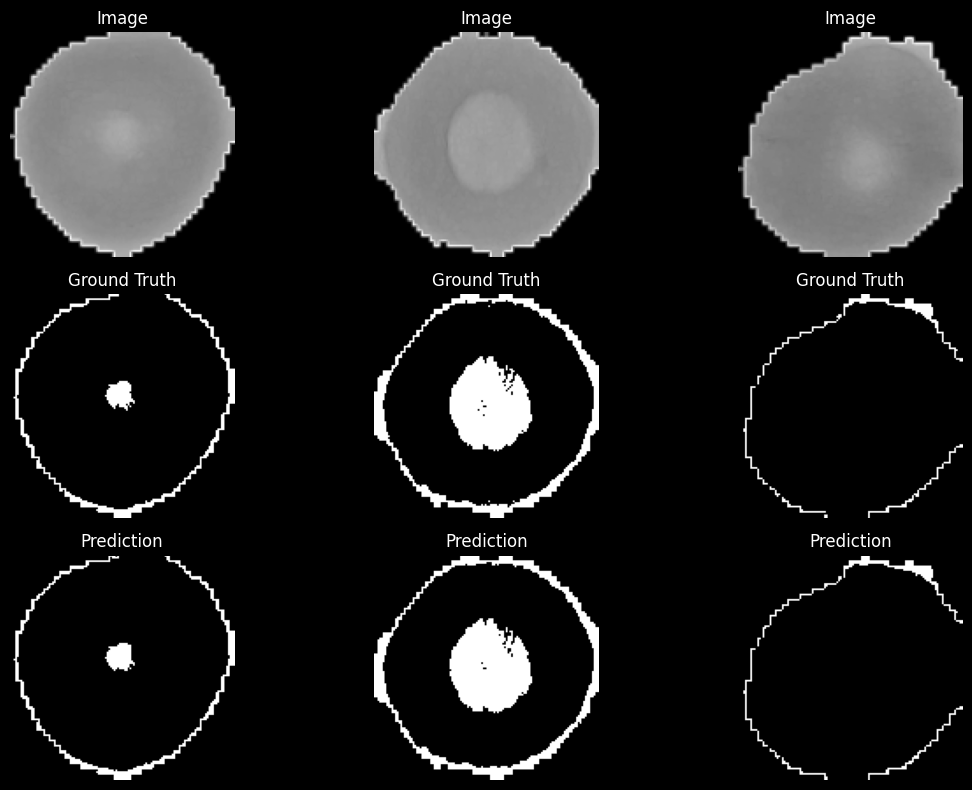

In [13]:
images, masks = next(iter(test_loader))
images = images.to(device)

preds = model(images)

images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.detach().cpu().numpy()

plt.figure(figsize=(12,8))

for i in range(3):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3,3,i+4)
    plt.imshow(masks[i][0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3,3,i+7)
    plt.imshow(preds[i][0] > 0.5, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

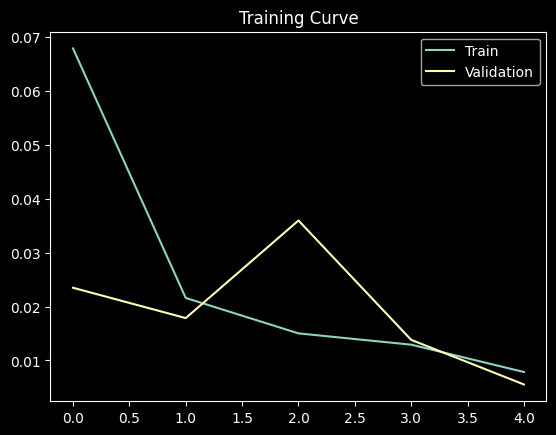

In [14]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Training Curve")
plt.show()